In [1]:
!pip install shap   #SHapley Additive exPlanations

ERROR: Invalid requirement: '#SHapley': Expected package name at the start of dependency specifier
    #SHapley
    ^


In [14]:
import pandas as pd
import numpy as np
import joblib
import shap
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv('creditcard.csv')
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load saved model
rf = joblib.load('fraud_model.pkl')

print("Data loaded ✅")
print("Model loaded ✅")
print("Test shape:", X_test.shape)

Data loaded ✅
Model loaded ✅
Test shape: (56962, 30)


In [15]:
# Take small sample
X_test_sample = X_test.sample(100, random_state=42)

# SHAP explainer 
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated ✅")
print("Shape:", shap_values[1].shape)

SHAP values calculated ✅
Shape: (30, 2)


In [16]:
# Check shapes
print("SHAP values type:", type(shap_values))
print("SHAP values length:", len(shap_values))
print("SHAP values[0] shape:", shap_values[0].shape)
print("SHAP values[1] shape:", shap_values[1].shape)
print("X_test_sample shape:", X_test_sample.shape)

SHAP values type: <class 'numpy.ndarray'>
SHAP values length: 100
SHAP values[0] shape: (30, 2)
SHAP values[1] shape: (30, 2)
X_test_sample shape: (100, 30)


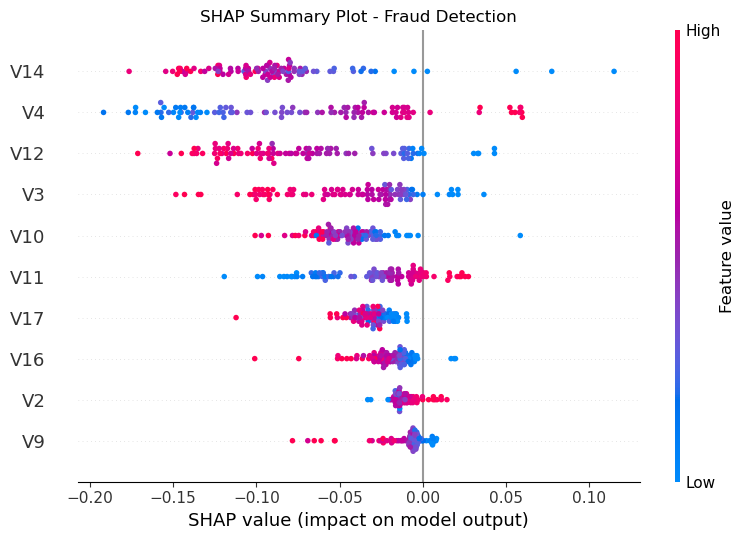

Summary plot saved ✅


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,5))
shap.summary_plot(shap_values[:,:,1], X_test_sample, show=False,max_display=10)
plt.title("SHAP Summary Plot - Fraud Detection")
plt.tight_layout()
plt.savefig('shap_summary.png')
plt.show()
print("Summary plot saved ✅")

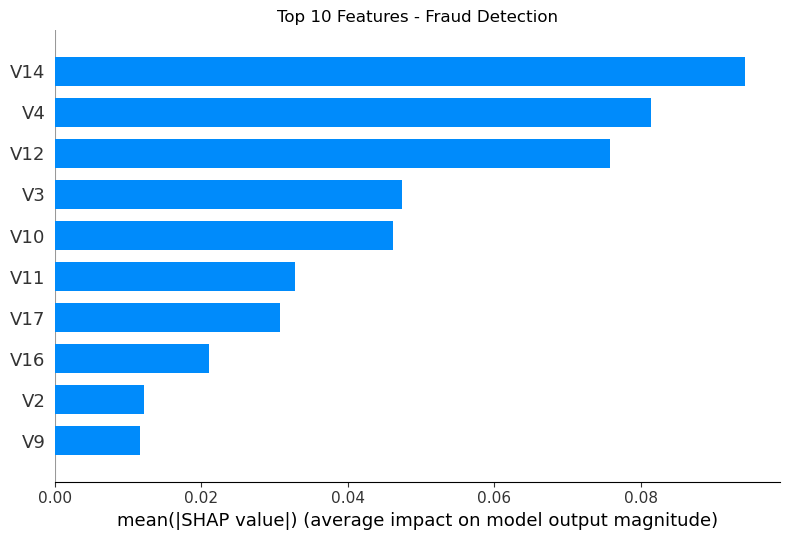

Bar plot saved ✅


In [18]:
shap_values_fraud = shap_values[:, :, 1]
shap.summary_plot(shap_values_fraud, X_test_sample,
                  plot_type="bar",
                  show=False,
                  max_display=10)
plt.title("Top 10 Features - Fraud Detection")
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()
print("Bar plot saved ✅")